# Equity Risk & Return Analysis

## Context

You are a quantitative researcher evaluating a small universe of US equities. Your task is to
characterise the **risk and return** of each asset relative to the market using the
**Capital Asset Pricing Model (CAPM)**, and to draw conclusions a portfolio manager could act on.

The CAPM describes the relationship between an asset's expected excess return and its
sensitivity to the market:

$$ R_i - R_f = \alpha_i + \beta_i \,(R_m - R_f) + \varepsilon_i $$

where:
- $R_i$ — return of asset $i$
- $R_f$ — risk-free rate
- $R_m$ — market return (we use a broad market ETF as proxy)
- $\beta_i$ — market sensitivity (systematic risk)
- $\alpha_i$ — Jensen's alpha (return not explained by market exposure)

## What you must deliver

1. Acquire and clean the data (Section 1)
2. Compute excess returns (Section 2)
3. Estimate CAPM $\alpha$ and $\beta$ for each asset via OLS (Section 3)
4. Compute and interpret the Sharpe ratio for each asset (Section 4)
5. Build a simple long–short view and evaluate it (Section 5)
6. Write up your conclusions (Section 6)

In [ ]:
# !pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.random.seed(42)

TICKERS = ["AAPL", "MSFT", "JNJ", "JPM", "XOM", "KO"]
MARKET = "SPY"
START = "2019-01-01"
END = "2024-01-01"

RF_ANNUAL = 0.04
TRADING_DAYS = 252
RF_DAILY = RF_ANNUAL / TRADING_DAYS

## Section 1 | Data acquisition & cleaning

Download daily **adjusted close** prices for the universe and the market proxy, then convert
to daily simple returns.

**Tasks**
- Download prices for `TICKERS + [MARKET]` between `START` and `END`.
- Handle any missing values sensibly and explain your choice.
- Convert prices to daily simple returns.

In [3]:
prices = yf.download(TICKERS + [MARKET], start=START, end=END, auto_adjust=True)["Close"]
print('shape:', prices.shape)
print("mising val:\n", prices.isna().sum())
prices.head()

[*********************100%***********************]  7 of 7 completed

shape: (1258, 7)
mising val:
 Ticker
AAPL    0
JNJ     0
JPM     0
KO      0
MSFT    0
SPY     0
XOM     0
dtype: int64


Ticker,AAPL,JNJ,JPM,KO,MSFT,SPY,XOM
Date,,,,,,,
2019-01-02,37.4692,103.7910,80.8365,37.5827,94.1931,224.3825,49.6647
2019-01-03,33.7370,102.1417,79.6877,37.3504,90.7279,219.0282,48.9022
2019-01-04,35.1772,103.8560,82.6254,38.0952,94.9477,226.3647,50.7052
2019-01-07,35.0989,103.1898,82.6828,37.5987,95.0687,228.1495,50.9689
2019-01-08,35.7680,105.5865,82.5269,38.0231,95.7580,230.2930,51.3395


In [4]:
prices = prices.dropna()

returns = prices.pct_change().dropna()
print("Returns shape:", returns.shape)
returns.head()

Returns shape: (1257, 7)


Ticker,AAPL,JNJ,JPM,KO,MSFT,SPY,XOM
Date,,,,,,,
2019-01-03,-0.0996,-0.0159,-0.0142,-0.0062,-0.0368,-0.0239,-0.0154
2019-01-04,0.0427,0.0168,0.0369,0.0199,0.0465,0.0335,0.0369
2019-01-07,-0.0022,-0.0064,0.0007,-0.0130,0.0013,0.0079,0.0052
2019-01-08,0.0191,0.0232,-0.0019,0.0113,0.0073,0.0094,0.0073
2019-01-09,0.0170,-0.0079,-0.0017,-0.0192,0.0143,0.0047,0.0053


# Why "Close" and not "Open", "High", or "Low"
The other columns exist (Open, High, Low), but close is the standard for return calculations because:

- **It's the consensus end-of-day price**: the value after all the day's trading has settled, the most "informationally complete" price of the day.
- **Consistency**: measuring close-to-close gives a clean daily return series. Mixing, say, open-to-close would conflate overnight gaps with intraday moves.
- **Convention**: the entire academic and industry literature (including Ken French) uses close-based total returns, so you stay comparable.

Open is noisy (gaps, overnight news), and High/Low are intraday extremes that don't represent a price you could reliably transact the whole position at. Close is the sensible default.

While backfill and interpolation would cause lookahead bias, forward filling prices would risk to create fake zero return.

# Section 2 | Excess returns

CAPM is expressed in **excess** terms (returns above the risk-free rate).

**Tasks**
- Subtract the daily risk-free rate from every asset and from the market.
- Produce a clean `excess` DataFrame (assets) and an `excess_mkt` Series (market).

In [5]:
excess = returns[TICKERS] - RF_DAILY
excess_mkt = returns[MARKET] - RF_DAILY

excess.describe()

Ticker,AAPL,MSFT,JNJ,JPM,XOM,KO
count,"1,257.0000","1,257.0000","1,257.0000","1,257.0000","1,257.0000","1,257.0000"
mean,0.0013,0.0011,0.0002,0.0006,0.0006,0.0002
std,0.0203,0.0192,0.0125,0.0201,0.0216,0.0135
min,-0.1288,-0.1475,-0.0731,-0.1498,-0.1224,-0.0969
25%,-0.0084,-0.0085,-0.0058,-0.0086,-0.0110,-0.0054
50%,0.0013,0.0011,0.0001,0.0005,0.0003,0.0006
75%,0.0123,0.0110,0.0060,0.0095,0.0114,0.0064
max,0.1196,0.1420,0.0798,0.1800,0.1267,0.0646


# Section 3 | CAPM estimation via OLS

For each asset, regress its **excess return** on the **market excess return**:

$$ (R_i - R_f) = \alpha_i + \beta_i (R_m - R_f) + \varepsilon_i $$

**Tasks**
- For each ticker, fit an OLS regression with an intercept.
- Collect $\alpha$ (intercept), $\beta$ (slope), the $t$-statistic on $\alpha$, and $R^2$.
- Annualise alpha (daily alpha × 252) for interpretability.
- Present results in a tidy table sorted by beta.

In [6]:
rows = []
X = sm.add_constant(excess_mkt)

for tic in TICKERS:
    y = excess[tic]
    model = sm.OLS(y, X).fit()
    alpha_daily = model.params["const"]
    beta        = model.params[MARKET]

    rows.append({
        "ticker"    : tic,
        "beta"      : beta,
        "alpha_daily": alpha_daily,
        "alpha_annual": alpha_daily * TRADING_DAYS,
        "alpha_tstat": model.tvalues["const"],
        "r_squared" : model.rsquared, 
    })

capm = pd.DataFrame(rows).set_index("ticker").sort_values("beta")
capm

,beta,alpha_daily,alpha_annual,alpha_tstat,r_squared
ticker,,,,,
JNJ,0.5273,-0.0001,-0.0193,-0.2605,0.3107
KO,0.6573,-0.0001,-0.0236,-0.3226,0.4161
XOM,0.9005,0.0001,0.0278,0.2169,0.3043
JPM,1.1123,0.0000,0.0075,0.0771,0.5360
MSFT,1.1975,0.0005,0.1279,1.6547,0.6799
AAPL,1.2352,0.0007,0.1809,2.1079,0.6473


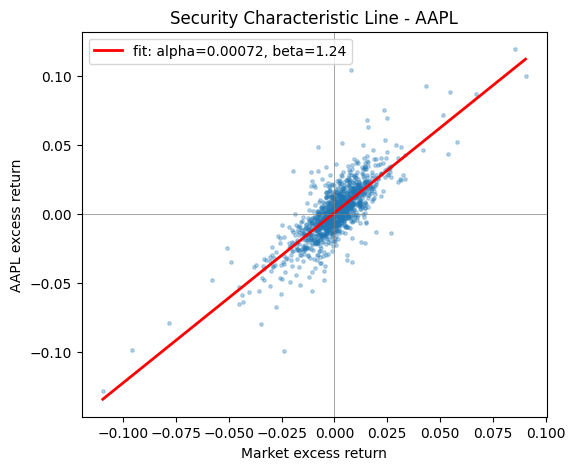

In [7]:
tic = "AAPL"
plt.figure(figsize=(6,5))
plt.scatter(excess_mkt, excess[tic], s=6, alpha=0.3)
xs = np.linspace(excess_mkt.min(), excess_mkt.max(), 100)
b = capm.loc[tic, "beta"]
a = capm.loc[tic, "alpha_daily"]
plt.plot(xs, a+b*xs, color="red", linewidth=2, label=f"fit: alpha={a:.5f}, beta={b:.2f}")
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("Market excess return")
plt.ylabel(f"{tic} excess return")
plt.title(f"Security Characteristic Line - {tic}")
plt.legend()
plt.show()

**Interpret the beta estimates. Which assets are defensive
(β < 1) and which are aggressive (β > 1)? Does the ordering match your economic intuition given
the sectors involved (tech, healthcare, banking, energy, consumer staples)?**

B>1 means aggresive, 0<B<1 means defensive, while B<0 means moves against the market or negatively correlated. My intuition, AAPL & MSFT is high beta because tech stock. and KO & JNJ because of the retail, it is always sold. Not sure for XOM & JPM.

JPM I'd expect aggressive — banks are highly cyclical, amplifying booms and busts through lending and defaults. XOM is the trickiest: energy is cyclical (suggesting β > 1), but oil-price dynamics partly decouple it from the broad market, so its beta may be lower or less stable than its cyclicality implies.

**Look at the alpha $t$-statistics. Are any alphas statistically
significant at the 5% level (|t| > ~1.96)? Given CAPM theory, should we *expect* persistent
non-zero alpha? What would a significant positive alpha imply, and why should you be skeptical?**

Only AAPL surpasses 1.96 (5%). MSFT is suggestive but doesnt clear the 5% bar. The rest have t abs below 1, meaning their alpha indistinguishable from zero. This is consistent with CAPM which predicts alpha should be zero. AAPL positive alpha would imply return the market factor cant explain.

But im skeptical: testing 6 stock at 5% means ~1 will appear significant by chance (multiple testing), t=2.11 is marginal, the estimate is in-sample and as a mega cap growth name AAPL's "alpha" is likely just size/value exposure that a Fama-French model would absorb.

**Is more factor always better (Fama-French)?**

**How you'd actually decide**

For the question "is FF3 worth it here?", you'd check:

- Do SMB/HML loadings come out statistically significant? If a stock's HML beta has |t| < 2, that factor isn't doing anything for that stock — CAPM was fine.  
- Does the alpha's significance change meaningfully? If AAPL's t-stat drops from 2.11 to ~0 under FF3, the extra factors earned their keep (they revealed the "alpha" was factor exposure). If nothing changes, they didn't help.  
- Does it hold out-of-sample? In-sample improvement is cheap; out-of-sample improvement is real.


**The one-line answer**


No, FF3 isn't always better — "more factors" mechanically improves in-sample fit even when the factors are useless, so the real question is whether the added factors are economically justified and genuinely improve out-of-sample explanation for your specific problem. FF3 beats CAPM for separating skill from factor exposure on US equities, but CAPM can be the better tool when you're data-poor, want interpretability, or only care about market risk — and both fall short when your universe is non-US or driven by factors neither model includes. The skill isn't "use the biggest model," it's matching model complexity to the question and the data.




"Persistent non-zero alpha" = unexplained outperformance that reliably recurs over time, not just a one-off lucky reading. "Non-zero" means there's an edge; "persistent" means it keeps happening — which is what distinguishes real skill from noise. And the reason 3b asks whether we should expect it: efficient-market theory says no, because any reliable, persistent edge would be spotted and arbitraged away — so persistent alpha is exactly what shouldn't survive in an efficient market, making any claim to have found it something you treat with deep skepticism.

To note there are 2 CAPM model

1. Portfolio (bucket) alpha/beta — measures the PM's overall performance. Run the regression on the whole book's returns. Alpha here = the PM's skill (value added beyond risk exposure). Beta = the book's market risk.
2. Single-stock alpha/beta — measures one stock. Beta = that stock's risk/sensitivity to the market. Alpha = that stock's unexplained return.

# Section 4 | Sharpe ratios

The **Sharpe ratio** measures risk-adjusted return:

$$ \text{Sharpe} = \frac{\overline{R_i - R_f}}{\sigma_{R_i - R_f}} $$

**Tasks**
- Compute the **annualised** Sharpe ratio for each asset.
- Annualise correctly: multiply mean daily excess return by 252 and daily std by √252.
- Add Sharpe to your results table and comment.

In [8]:
sharpe = (excess.mean()*TRADING_DAYS) / (excess.std() * np.sqrt(TRADING_DAYS))
capm["sharpe_annual"] = sharpe
capm.sort_values("sharpe_annual", ascending=False)

,beta,alpha_daily,alpha_annual,alpha_tstat,r_squared,sharpe_annual
ticker,,,,,,
AAPL,1.2352,0.0007,0.1809,2.1079,0.6473,1.0487
MSFT,1.1975,0.0005,0.1279,1.6547,0.6799,0.9193
JPM,1.1123,0.0000,0.0075,0.0771,0.5360,0.4672
XOM,0.9005,0.0001,0.0278,0.2169,0.3043,0.4153
KO,0.6573,-0.0001,-0.0236,-0.3226,0.4161,0.2804
JNJ,0.5273,-0.0001,-0.0193,-0.2605,0.3107,0.2408


**Which asset has the best risk-adjusted return? Note that a high
*raw* return and a high *Sharpe* are not the same thing? explain the distinction using two
specific assets from your table.**

AAPL as the best risk-adjusted return (Sharpe 1.05). The distinction between raw return (Ri) amd Sharpe shows in comparing JPM (Sharpe 0.47) and XOM (Sharpe 0.42): although JPM is the more volatile, higher-beta name and likely earned a higher raw return, their sharpes are nearly identical - meaning JPM's extra raw return was achieved by taking proportionally more risk, so it offered no real risk adjusted advantage. A high raw return only impresses if it isnt simply paid for with higher volatility, which is exactly what Sharpe exposes.

**But what if Risk Free rate (Rf) is bigger than Raw Return (Ri), what would be a sign?**

The clearest read across all your tables: **negative Sharpe ratios everywhere** is the unmistakable fingerprint of "the market underperformed the risk-free rate". That's the single most direct sign in your output - it literally says "holding cash beats holding these stocks, risk adjusted"

And the deeper interpretation: in this country/period, investors weren't compensated for taking equity risk. The fundamental bargain of CAPM - take more risk (beta), earn more return - broke down and inverted. Rational investors would have preferred the risk free asset. This is exactly the kind of regime where you'd question whether the equity market is investable at all, or whether the risk free is so high (e.g. high inflation economy) that it distors everything.

# Section 5 | A simple long-short view

Construct a naive dollar-neutral view from your CAPM alphas:
- Long the asset with the highest annualised alpha
- Short the asset with the lowest annualised alpha
- Equal weight (+1 / -1), rebalanced daily (assume no transaction costs)

**Tasks**
- Build the daily P&L series of this long short book
- Compute its annualised sharpe ratio
- Plot the cumulative return

LONG AAPL / SHORT KO
Long-short annualised Sharpe: 0.93


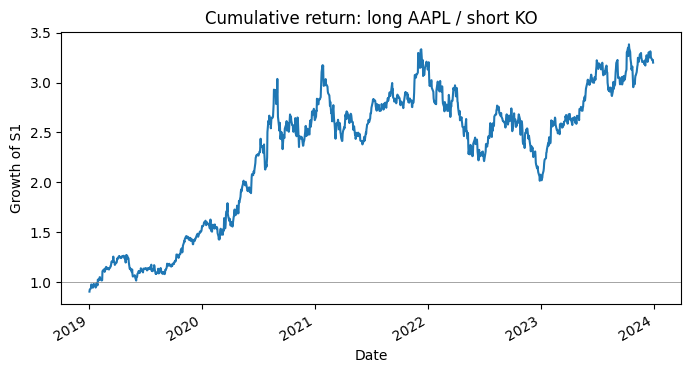

In [16]:
long_tic = capm["alpha_annual"].idxmax()
short_tic = capm["alpha_annual"].idxmin()
print(f"LONG {long_tic} / SHORT {short_tic}")

ls_pnl = returns[long_tic] - returns[short_tic]
ls_sharpe = (ls_pnl.mean() * TRADING_DAYS) / (ls_pnl.std() * np.sqrt(TRADING_DAYS))
print(f"Long-short annualised Sharpe: {ls_sharpe:.2f}")

cum = (1 + ls_pnl).cumprod()
plt.figure(figsize=(8,4))
cum.plot()
plt.title(f"Cumulative return: long {long_tic} / short {short_tic}")
plt.ylabel("Growth of S1")
plt.axhline(1, color="grey", lw=0.5)
plt.show()

# Why dont we do this?

LONG AAPL / SHORT KO
Long-short annualised Sharpe: 1.05


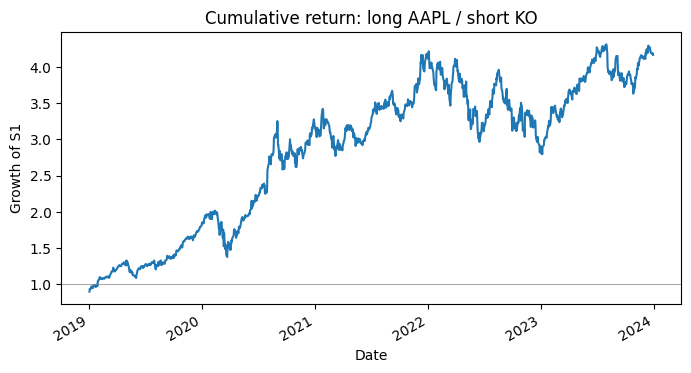

In [18]:
long_tic = capm["alpha_annual"].idxmax()
short_tic = capm["alpha_annual"].idxmin()
print(f"LONG {long_tic} / SHORT {short_tic}")

ls_pnl = excess[long_tic]
ls_sharpe = (ls_pnl.mean() * TRADING_DAYS) / (ls_pnl.std() * np.sqrt(TRADING_DAYS))
print(f"Long-short annualised Sharpe: {ls_sharpe:.2f}")

cum = (1 + ls_pnl).cumprod()
plt.figure(figsize=(8,4))
cum.plot()
plt.title(f"Cumulative return: long {long_tic} / short {short_tic}")
plt.ylabel("Growth of S1")
plt.axhline(1, color="grey", lw=0.5)
plt.show()

**What the short leg is actually for: it's insurance against the market**

**But in the crash, maybe KO is not really affected by the crash, because the beta is small (although not the smallest)**

Your reasoning is correct. The hedge is only works if the leg moves with the market. But KO is defensive (beta~0.66) and AAPL is aggresive (beta~1.24). So in a crash:

- AAPL (beta 1.24) drops ~37% (market 30% * 1.24)
- KO (beta 0.66) drops only ~20% (market ~30% * 0.66)

Your're long the thing that falls hard and short the thing that falls soft. Your short doesnt generate enough gain to offset your long loss. Net, you still lose in the crash - the "hedge" only partially works because the betas dont match.

The name for this: the book isn't beta-neutral

This is the key concept. The naive construction is dollar-neutral. (+$1 long, $1 short, nets to $0 of capital) - but it is not beta-neutral. Lets compute the net beta:

Beta book = (+1 X 1.24) + (-1 X 0.66) = +0.58

A net beta +0.58 means the book still has substantial market exposure - it behaves like being ~58% long the market. So it's not market-neutral at all. In a crash, that residual +0.58 beta is exactly what bleeds you. You correctly sensed this.

**The fix: weight by beta, not by dollars**

Professionals dont short equal dollars - they short enough of the low-beta name to cancel the beta. To neutralize AAPL's 1.24 of beta using KO's 0.66, you short more KO.

short ratio = 1.24/0.66 = 1.88

So: Long $1 of AAPL, short $1.88 of KO. Now the net beta.

(+1 X 1.24) + (-1.88 X 0.66) = 1.24 - 1.24 = 0

**Beta-neutral**. How a market crash hits both legs proportionally, they cancel and what's left is purely your alpha view (AAPL vs KO on a market-neutral basis). This is the hedge actually working.


# Section 5a | Beta-Neutral View

LONG AAPL (beta 1.24) / SHORT KO (beta 0.66)
Hedge ratio = 1.88 -> short $1.88 of KO per $1 of AAPL

Naive (dollar-neutral): net beta = +0.58 Sharpe = 0.93
Beta-neutral:           net beta = +0.00 Sharpe = 0.49


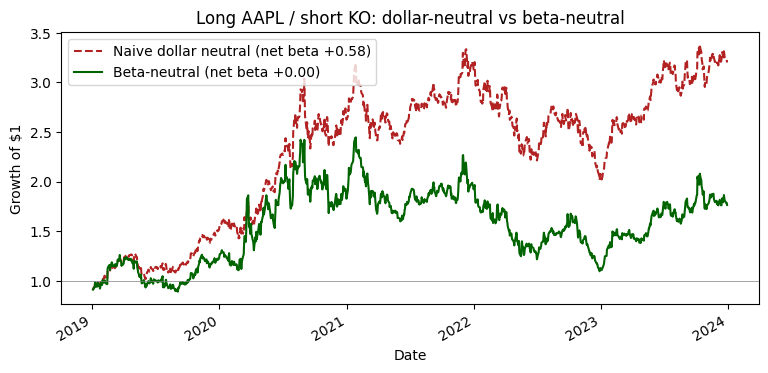

In [41]:
# Section 5C: Beta-neutral long-short
# The naive book above is Dollar-neutral (+$1/-$1) but NOT beta-neutral
# If the legs have different betas, the book keeps leftover market exposure
# Fix: size the short by the beta ratio so net beta = 0

long_tic = capm["alpha_annual"].idxmax()
short_tic = capm["alpha_annual"].idxmin()

beta_long = capm.loc[long_tic, "beta"]
beta_short = capm.loc[short_tic, "beta"]
hedge_ratio = beta_long/beta_short

print(f"LONG {long_tic} (beta {beta_long:.2f}) / SHORT {short_tic} (beta {beta_short:.2f})")
print(f"Hedge ratio = {hedge_ratio:.2f} -> short ${hedge_ratio:.2f} of {short_tic} per $1 of {long_tic}")

naive_pnl = returns[long_tic] - returns[short_tic]
bn_pnl = returns[long_tic] - hedge_ratio*returns[short_tic]

naive_net_beta = beta_long - beta_short
bn_net_beta = beta_long - hedge_ratio * beta_short

def ann_sharpe(s):
    return (s.mean() * TRADING_DAYS) / (s.std() * np.sqrt(TRADING_DAYS))

print(f"\nNaive (dollar-neutral): net beta = {naive_net_beta:+.2f} Sharpe = {ann_sharpe(naive_pnl):.2f}")
print(f"Beta-neutral:           net beta = {bn_net_beta:+.2f} Sharpe = {ann_sharpe(bn_pnl):.2f}")

cum_naive = (1 + naive_pnl).cumprod()
cum_bn = (1 + bn_pnl).cumprod()

plt.figure(figsize=(9,4))
cum_naive.plot(label=f"Naive dollar neutral (net beta {naive_net_beta:+.2f})", color="firebrick", ls="--")
cum_bn.plot(label=f"Beta-neutral (net beta {bn_net_beta:+.2f})", color="darkgreen")
plt.axhline(1, color="grey", lw=0.5)
plt.title(f"Long {long_tic} / short {short_tic}: dollar-neutral vs beta-neutral")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

Utang:

Section 5b

Section 5b x beta neutral

# Section 6 | Conclusions

**CAPM analysis - 6 stocks US universe (2019-2023)**

The universe spans the risk spectrum: AAPL (β 1.24) and MSFT (β 1.20) are aggresive, amplifying market moves, while JNJ (β 0.53) and KO (β 0.66) are defensive. This is intuituve given the sectors - tech is cyclical, staples and healthcare are stable.

I found **no credible evidence of alpha**. Only AAPL's alpha was statistically significant (t=2.11), and even that is marginal and likely just uncompressed size/value exposure rather than skill - consistent with efficient markets, where persistent alpha shouldn't survive.

On a risk-adjusted basis, **AAPL is most attractive** (Sharpe 1.05), though its returns campe partly from taking more risk.

Two key limitations: (1) single-factor CAPM mislables factor exposure as alpha - I'd extend to Fama-French 3/5 factor model; (2) all estimates are in-sample - I'd validate out-of-sample via walk-forward testing before trading.